In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

In [2]:
# Parameters

E=1
dm2 = 1
theta =0.195
sin_2th   = np.sin(2*theta)
cos_2th   = np.cos(2*theta)
omega = dm2/(4.0*E)

bx = omega * np.sin(2 * theta)
by = 0.0
bz = -omega * np.cos(2 * theta)

# number of nu #
N = 4

In [3]:
def interaction_matrix(N, dm2, E):
    """
    Build Jij = (dm2 / 4E) * (1 - cos(theta_ij)),
    with theta_ij = arccos(0.9) * |i-j|/(N-1).
    """
    i = np.arange(N)
    dij = np.abs(i[:, None] - i[None, :])   # |i-j|
    theta = np.arccos(0.9) * dij / (N - 1)
    J = (dm2 / (4.0 * E)) * (1.0 - np.cos(theta))
    return J

In [4]:
# -------------------------------------------------
# Add vacuum evolution to an existing circuit
# -------------------------------------------------
def add_vacuum_evolution(qc, n, bx, by, bz, N):
    """
    Add n first-order vacuum steps to the circuit.

    Each step applies:
        exp[-i (bx X_i + by Y_i + bz Z_i)]
    approximately as
        RX(2bx) RY(2by) RZ(2bz)
    on every qubit i.
    """
    for _ in range(n):
        for q in range(N):
            qc.rx(2.0 * bx, q)
            qc.ry(2.0 * by, q)
            qc.rz(2.0 * bz, q)


# -------------------------------------------------
# Add interaction evolution to an existing circuit
# -------------------------------------------------
def add_interaction_evolution(qc, n, J, N):
    """
    Add n first-order interaction steps to the circuit.

    For each pair (i,j), apply
        exp[-i Jij (XX + YY + ZZ)]
    as
        RXX(2 Jij) RYY(2 Jij) RZZ(2 Jij)
    """
    for _ in range(n):
        for i in range(N):
            for j in range(i + 1, N):
                phi = 2.0 * J[i, j]
                qc.rxx(phi, i, j)
                qc.ryy(phi, i, j)
                qc.rzz(phi, i, j)

In [5]:
def build_full_circuit(qc0, n, bx, by, bz, J, N):
    qc = qc0.copy()

    add_vacuum_evolution(qc, n, bx, by, bz, N)
    add_interaction_evolution(qc, n, J, N)

    qc.measure(range(N), range(N))
    return qc

In [6]:
# Interaction matrix
J = interaction_matrix(N, dm2, E)

# Initial state prepared outside
qc0 = QuantumCircuit(N, N)
qc0.x(2)# example: qubit 1 is nu_mu, others nu_e
qc0.x(3)

# Build evolved circuit
qc = build_full_circuit(qc0, n=10, bx=bx, by=by, bz=bz, J=J, N=N)

# print(qc.draw())

In [7]:
# backend = AerSimulator()
# shots = 4096
# n_steps_max = 40

# for n in range(n_steps_max + 1):
#     qc = build_full_circuit(qc0, n=n, bx=bx, by=by, bz=bz, J=J, N=N)
#     tqc = transpile(qc, backend)
#     counts = backend.run(tqc, shots=shots).result().get_counts()
#     print(f"t = {n:2d}, counts = {counts}")

In [32]:
P_nue_q0 = []
P_numu_q1 = []
P_nue_q0_INV = []
P_numu_q1_INV = []

times = []

backend = AerSimulator()
shots = 4096
n_steps_max = 40

for n in range(n_steps_max + 1):
    qc = build_full_circuit(qc0, n=n, bx=bx, by=by, bz=bz, J=J, N=N)
    tqc = transpile(qc, backend)
    counts = backend.run(tqc, shots=shots).result().get_counts()

    p0_nue = 0.0
    p1_numu = 0.0

    for bitstring, c in counts.items():
        # rightmost bit is qubit 0, next is qubit 1
        q0 = int(bitstring[-1])
        q1 = int(bitstring[-2])

        if q0 == 0:
            p0_nue += c / shots
        if q1 == 1:
            p1_numu += c / shots

    times.append(n)
    P_nue_q0.append(p0_nue)
    P_numu_q1.append(p1_numu)
    P_nue_q0_INV.append(1-p0_nue)
    P_numu_q1_INV.append(1-p1_numu)

#     print(f"t = {n:2d}, counts = {counts}, P(q0=nu_e) = {p0_nue:.4f}, P(q1=nu_mu) = {p1_numu:.4f}")

t =  0, counts = {'1100': 4096}, P(q0=nu_e) = 1.0000, P(q1=nu_mu) = 0.0000
t =  1, counts = {'1100': 3923, '1110': 41, '0101': 10, '1101': 40, '0100': 45, '1000': 31, '1010': 1, '1001': 3, '0110': 1, '1011': 1}, P(q0=nu_e) = 0.9868, P(q1=nu_mu) = 0.0107
t =  2, counts = {'1100': 3507, '1000': 137, '0100': 133, '1101': 125, '0111': 4, '1001': 14, '0101': 36, '1110': 111, '0001': 4, '1111': 4, '0110': 9, '1010': 5, '0010': 1, '0000': 6}, P(q0=nu_e) = 0.9543, P(q1=nu_mu) = 0.0327
t =  3, counts = {'1100': 3020, '1000': 210, '0000': 18, '1101': 219, '0100': 232, '1110': 219, '0101': 74, '1001': 36, '0111': 4, '1111': 15, '1010': 12, '0001': 7, '0110': 24, '0011': 4, '1011': 2}, P(q0=nu_e) = 0.9119, P(q1=nu_mu) = 0.0684
t =  4, counts = {'1000': 254, '1100': 2513, '1101': 306, '0100': 333, '1001': 55, '0001': 33, '1110': 284, '0111': 22, '0101': 110, '1010': 38, '0110': 50, '1111': 33, '0000': 42, '0010': 10, '0011': 6, '1011': 7}, P(q0=nu_e) = 0.8604, P(q1=nu_mu) = 0.1099
t =  5, counts = 

t = 34, counts = {'0011': 342, '1100': 923, '0101': 1305, '1000': 164, '0001': 279, '1010': 207, '1001': 65, '0110': 42, '0100': 107, '0111': 213, '1110': 158, '1101': 123, '0010': 40, '1111': 28, '1011': 54, '0000': 46}, P(q0=nu_e) = 0.4119, P(q1=nu_mu) = 0.2646
t = 35, counts = {'1110': 105, '0101': 1417, '1100': 1131, '0011': 412, '0001': 149, '1010': 236, '1000': 127, '0111': 141, '1101': 89, '1001': 61, '1011': 52, '0100': 87, '0010': 36, '0110': 31, '0000': 13, '1111': 9}, P(q0=nu_e) = 0.4312, P(q1=nu_mu) = 0.2495
t = 36, counts = {'1110': 68, '0101': 1494, '0011': 415, '1100': 1365, '1001': 51, '1010': 331, '1101': 46, '1000': 67, '0111': 67, '1011': 27, '0110': 42, '0001': 64, '0100': 38, '0010': 18, '0000': 3}, P(q0=nu_e) = 0.4717, P(q1=nu_mu) = 0.2363
t = 37, counts = {'0101': 1417, '1001': 78, '0001': 8, '1010': 457, '1100': 1577, '0011': 459, '0110': 37, '1101': 11, '0111': 5, '0010': 4, '0100': 5, '1000': 16, '1110': 14, '1011': 7, '0000': 1}, P(q0=nu_e) = 0.5154, P(q1=nu_

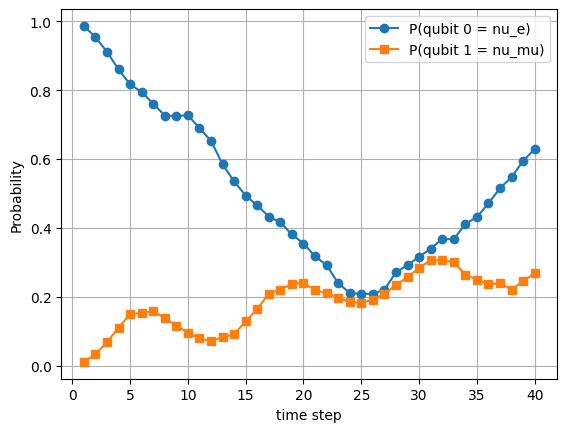

In [34]:
# plt.plot(times[1:], P_nue_q0_INV[1:], marker='o', label='P_inv(qubit 0 = nu_e)')
# plt.plot(times[1:], P_numu_q1_INV[1:], marker='s', label='P_inv(qubit 1 = nu_mu)')
plt.plot(times[1:], P_nue_q0[1:], marker='o', label='P(qubit 0 = nu_e)')
plt.plot(times[1:], P_numu_q1[1:], marker='s', label='P(qubit 1 = nu_mu)')
plt.plot(times[1:], P_nue_q2[1:], marker='o', label='P(qubit 0 = nu_e)')
plt.plot(times[1:], P_numu_q3[1:], marker='s', label='P(qubit 1 = nu_mu)')
plt.xlabel('time step')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
import matplotlib.pyplot as plt
from qiskit import transpile
from qiskit_aer import AerSimulator

initial_bits = [0, 0, 1, 1]

P_inv = [[] for _ in range(N)]
times = []

backend = AerSimulator()
shots = 4096
n_steps_max = 40

for n in range(n_steps_max + 1):
    qc=qc0.copy()
    add_vacuum_evolution(qc, n=n, bx=bx, by=by, bz=bz, N=N)
    add_interaction_evolution(qc, n=n, J=J, N=N)
#     tqc = transpile(qc, backend)
#     counts = backend.run(tqc, shots=shots).result().get_counts()

    qc.measure(range(N), range(N))

    tqc = transpile(qc, backend)
    counts = backend.run(tqc, shots=shots).result().get_counts()

    p_inv_t = [0.0] * N

    for bitstring, c in counts.items():
        prob = c / shots

        for q in range(N):
            bit_q = int(bitstring[-1 - q])
            if bit_q != initial_bits[q]:
                p_inv_t[q] += prob

    times.append(n)

    for q in range(N):
        P_inv[q].append(p_inv_t[q])

    print(
        f"t = {n:2d} | "
        f"q0_inv = {p_inv_t[0]:.4f}, "
        f"q1_inv = {p_inv_t[1]:.4f}, "
        f"q2_inv = {p_inv_t[2]:.4f}, "
        f"q3_inv = {p_inv_t[3]:.4f}"
    )

t =  0 | q0_inv = 0.0000, q1_inv = 0.0000, q2_inv = 0.0000, q3_inv = 0.0000
t =  1 | q0_inv = 0.0107, q1_inv = 0.0098, q2_inv = 0.0081, q3_inv = 0.0122
t =  2 | q0_inv = 0.0427, q1_inv = 0.0344, q2_inv = 0.0371, q3_inv = 0.0437
t =  3 | q0_inv = 0.0872, q1_inv = 0.0815, q2_inv = 0.0667, q3_inv = 0.0974
t =  4 | q0_inv = 0.1362, q1_inv = 0.1113, q2_inv = 0.1040, q3_inv = 0.1382
t =  5 | q0_inv = 0.1946, q1_inv = 0.1467, q2_inv = 0.1306, q3_inv = 0.1873
t =  6 | q0_inv = 0.2236, q1_inv = 0.1545, q2_inv = 0.1707, q3_inv = 0.2168
t =  7 | q0_inv = 0.2439, q1_inv = 0.1536, q2_inv = 0.1606, q3_inv = 0.2444
t =  8 | q0_inv = 0.2495, q1_inv = 0.1431, q2_inv = 0.1396, q3_inv = 0.2517
t =  9 | q0_inv = 0.2722, q1_inv = 0.1245, q2_inv = 0.1228, q3_inv = 0.2805
t = 10 | q0_inv = 0.2844, q1_inv = 0.0947, q2_inv = 0.0964, q3_inv = 0.2830
t = 11 | q0_inv = 0.3184, q1_inv = 0.0759, q2_inv = 0.0706, q3_inv = 0.3257
t = 12 | q0_inv = 0.3579, q1_inv = 0.0654, q2_inv = 0.0710, q3_inv = 0.3530
t = 13 | q0_

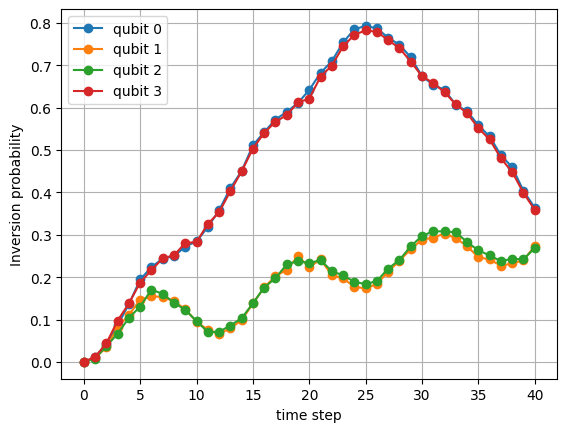

In [16]:
for q in range(N):
    plt.plot(times, P_inv[q], marker='o', label=f'qubit {q}')

plt.xlabel('time step')
plt.ylabel('Inversion probability')
plt.legend()
plt.grid(True)
plt.show()